# Instructions
- Some parts of the code are already done for you
- You need to execute all the cells
- You need to add the code where ever you see `"#### Add your code here ####"`
- Marks are mentioned along with the cells

# Face recognition
Task is to recognize a faces

### Dataset
**Aligned Face Dataset from Pinterest**

This dataset contains 10.770 images for 100 people. All images are taken from 'Pinterest' and      aligned using dlib library.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import tensorflow

In [3]:
print(tensorflow.__version__)

1.14.0


#### Mount Google drive if you are using google colab
- We recommend using Google Colab as you can face memory issues and longer runtimes while running on local

In [4]:
#from google.colab import drive
#drive.mount('/content/drive')

#I use my local GPU

#### Change current working directory to project folder (1 mark)

In [5]:
import os
project_path = './'
os.chdir(project_path)
print(os.getcwd())

/media/siju/DATA/work/FaceRecognition


### Extract the zip file (2 marks)
- Extract Aligned Face Dataset from Pinterest.zip

In [6]:
import zipfile
#This extracts the files to the current working directory
files_zip_path = project_path +'Aligned_Face_Dataset.zip'
archive = zipfile.ZipFile(files_zip_path, 'r')
archive.extractall()
!ls

 Aligned_Face_Dataset.zip  'R10_Project2_ACV_FaceRecognition (copy).ipynb'
 pins			    R10_Project2_ACV_FaceRecognition.ipynb
 PINS			    vgg_face_weights.h5


### Function to load images
- Define a function to load the images from the extracted folder and map each image with person id 


In [7]:
import numpy as np
import os

class IdentityMetadata():
    def __init__(self, base, name, file):
        # print(base, name, file)
        # dataset base directory
        self.base = base
        # identity name
        self.name = name
        # image file name
        self.file = file

    def __repr__(self):
        return self.image_path()

    def image_path(self):
        return os.path.join(self.base, self.name, self.file) 
    
def load_metadata(path):
    metadata = []
    for i in os.listdir(path):
        for f in os.listdir(os.path.join(path, i)):
            # Check file extension. Allow only jpg/jpeg' files.
            ext = os.path.splitext(f)[1]
            if ext == '.jpg' or ext == '.jpeg':
                metadata.append(IdentityMetadata(path, i, f))
    return np.array(metadata)

# metadata = load_metadata('images')
metadata = load_metadata('PINS')

In [8]:
print("Number of files:", len(metadata))

Number of files: 10770


### Define function to load image
- Define a function to load image from the metadata

In [9]:
import cv2
def load_image(path):
    img = cv2.imread(path, 1)
    # OpenCV loads images with color channels
    # in BGR order. So we need to reverse them
    return img[...,::-1]

#### Load a sample image (2 marks)
- Load one image using the function "load_image"

In [10]:
print(metadata[0].file)

Aaron Paul0_262.jpg


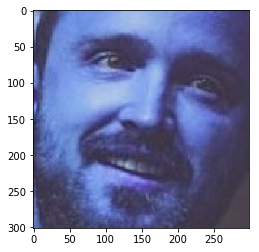

In [11]:
# Load an image
# for example, loading the image with index 1
one_image = load_image(metadata[0].image_path())
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure()
# Show original image
plt.imshow(cv2.cvtColor(one_image, cv2.COLOR_BGR2RGB))

### VGG Face model
- Here we are giving you the predefined model for VGG face

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ZeroPadding2D, Convolution2D, MaxPooling2D, Dropout, Flatten, Activation

def vgg_face():	
    model = Sequential()
    model.add(ZeroPadding2D((1,1),input_shape=(224,224, 3)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(Convolution2D(4096, (7, 7), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(4096, (1, 1), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(2622, (1, 1)))
    model.add(Flatten())
    model.add(Activation('softmax'))
    return model

#### Load the model (2 marks)
- Load the model defined above
- Then load the given weight file named "vgg_face_weights.h5"

In [13]:
model = vgg_face()

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [14]:
model.load_weights('vgg_face_weights.h5')

### Get vgg_face_descriptor

In [15]:
from tensorflow.keras.models import Model
vgg_face_descriptor = Model(inputs=model.layers[0].input, outputs=model.layers[-2].output)

In [16]:
vgg_face_descriptor.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
zero_padding2d_input (InputL [(None, 224, 224, 3)]     0         
_________________________________________________________________
zero_padding2d (ZeroPadding2 (None, 226, 226, 3)       0         
_________________________________________________________________
conv2d (Conv2D)              (None, 224, 224, 64)      1792      
_________________________________________________________________
zero_padding2d_1 (ZeroPaddin (None, 226, 226, 64)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 224, 224, 64)      36928     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 112, 112, 64)      0         
_________________________________________________________________
zero_padding2d_2 (ZeroPaddin (None, 114, 114, 64)      0     

### Generate embeddings for each image in the dataset
- Given below is an example to load the first image in the metadata and get its embedding vector from the pre-trained model. 

In [17]:
# Get embedding vector for first image in the metadata using the pre-trained model

img_path = metadata[0].image_path()
img = load_image(img_path)

# Normalising pixel values from [0-255] to [0-1]: scale RGB values to interval [0,1]
img = (img / 255.).astype(np.float32)

img = cv2.resize(img, dsize = (224,224))
print(img.shape)

# Obtain embedding vector for an image
# Get the embedding vector for the above image using vgg_face_descriptor model and print the shape 

embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
print(embedding_vector.shape)

(224, 224, 3)
(2622,)


### Generate embeddings for all images (5 marks)
- Write code to iterate through metadata and create embeddings for each image using `vgg_face_descriptor.predict()` and store in a list with name `embeddings`

- If there is any error in reading any image in the dataset, fill the emebdding vector of that image with 2622-zeroes as the final embedding from the model is of length 2622.

In [18]:
def get_face(img_path):
    img_data = cv2.imread(img_path)
    img_data = cv2.resize(img_data, (224, 224))
    return img_data

In [19]:
embeddings = []

for mdata in metadata:
    cropped_img = get_face(mdata.image_path())
    img = (cropped_img / 255.).astype(np.float32)
    embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
    embeddings.append(embedding_vector)

### Function to calculate distance between given 2 pairs of images.

- Consider distance metric as "Squared L2 distance"
- Squared l2 distance between 2 points (x1, y1) and (x2, y2) = (x1-x2)^2 + (y1-y2)^2

In [20]:
def distance(emb1, emb2):
    return np.sum(np.square(emb1 - emb2))

#### Plot images and get distance between the pairs given below
- 2, 3 and 2, 180
- 30, 31 and 30, 100
- 70, 72 and 70, 115

In [21]:
vars(metadata[0])

{'base': 'PINS', 'name': 'pins_Aaron Paul', 'file': 'Aaron Paul0_262.jpg'}

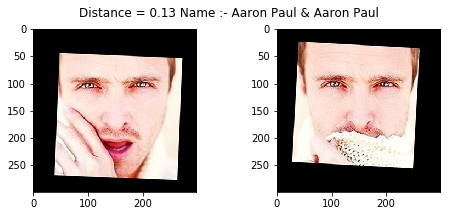

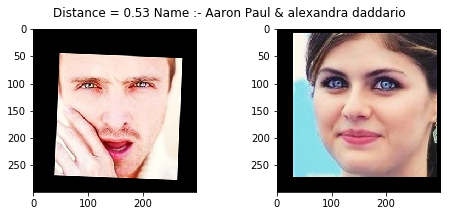

In [22]:
import matplotlib.pyplot as plt

def show_pair(idx1, idx2):
    plt.figure(figsize=(8,3))
    name = " Name :- " + metadata[idx1].name.strip('pins_') + " & " + metadata[idx2].name.strip('pins_')
    #print(name)
    plt.suptitle(f'Distance = {distance(embeddings[idx1], embeddings[idx2]):.2f}' + name)
    plt.subplot(121)
    plt.imshow(load_image(metadata[idx1].image_path()))
    plt.subplot(122)
    plt.imshow(load_image(metadata[idx2].image_path()));    

show_pair(2, 3)
show_pair(2, 180)

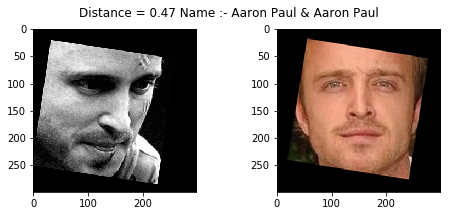

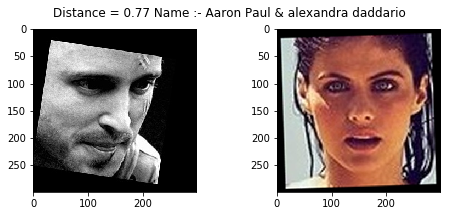

In [23]:
show_pair(30, 31)
show_pair(30, 100)

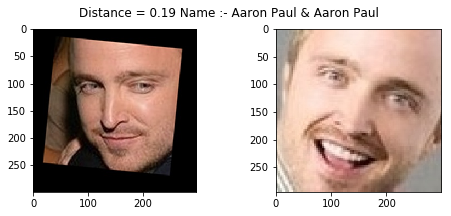

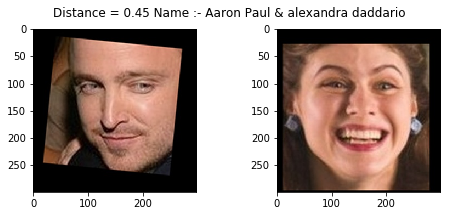

In [24]:
show_pair(70, 72)
show_pair(70, 115)

### Create train and test sets (5 marks)
- Create X_train, X_test and y_train, y_test
- Use train_idx to seperate out training features and labels
- Use test_idx to seperate out testing features and labels

In [25]:
train_idx = np.arange(metadata.shape[0]) % 9 != 0
test_idx = np.arange(metadata.shape[0]) % 9 == 0

In [26]:
train_idx.shape, test_idx.shape, metadata.shape

((10770,), (10770,), (10770,))

In [27]:
train_idx, test_idx

(array([False,  True,  True, ...,  True,  True,  True]),
 array([ True, False, False, ..., False, False, False]))

In [28]:
#Get targets from the metadata
targets = np.array([(m.name) for m in metadata])
targets.shape

(10770,)

In [29]:
num_classes = len(np.unique(targets))
print("Number of unique names =", num_classes)

Number of unique names = 100


In [30]:
X_train = np.array(embeddings)[train_idx]
X_test = np.array(embeddings)[test_idx]
y_train = targets[train_idx]
y_test = targets[test_idx]

### Encode the Labels (3 marks)
- Encode the targets
- Use LabelEncoder

In [31]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(targets)

# Numerical encoding of identities
y = encoder.transform(targets)
y_train = y[train_idx]
y_test = y[test_idx]

In [32]:
print("Total number of images      : {}".format(metadata.shape[0]))
print("Training Features Shape : {}".format(X_train.shape))
print("Training Labels Shape : {}".format(y_train.shape))
print("Test Features Shape : {}".format(X_test.shape))
print("Test Labels Shape  : {}".format(y_test.shape))

Total number of images      : 10770
Training Features Shape : (9573, 2622)
Training Labels Shape : (9573,)
Test Features Shape : (1197, 2622)
Test Labels Shape  : (1197,)


### Standardize the feature values (3 marks)
- Scale the features using StandardScaler

In [33]:
# Standarize features
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Reduce dimensions using PCA (3 marks)
- Reduce feature dimensions using Principal Component Analysis

In [34]:
from sklearn.decomposition import PCA

pca = PCA()
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [35]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([1.3600947e-01, 5.8562189e-02, 3.8071357e-02, ..., 1.5195516e-09,
       1.4742311e-09, 9.2246488e-11], dtype=float32)

### Build a Classifier (3 marks)
- Use SVM Classifier to predict the person in the given image
- Fit the classifier and print the score

In [36]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train, y_train)

SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)

In [37]:
from sklearn.metrics import f1_score, accuracy_score
acc_svc = accuracy_score(y_test, svc.predict(X_test))
print('SVM accuracy = {}'.format(acc_svc))

SVM accuracy = 0.9657477025898078


### Test results (1 mark)
- Take 10th image from test set and plot the image
- Report to which person(folder name in dataset) the image belongs to

In [38]:
import warnings
# Suppress LabelEncoder warning
warnings.filterwarnings('ignore')

def predict(example_idx):
    example_image = load_image(metadata[test_idx][example_idx].image_path())
    example_prediction = svc.predict(np.reshape(X_test[example_idx], (1, 2622)))
    example_identity = encoder.inverse_transform(example_prediction)[0]
    plt.imshow(example_image)
    pred = example_identity.strip("pins_")
    gt = metadata[test_idx][example_idx].name.strip("pins_")
    plt.title(f'Ground Truth: {gt} Identified as {pred}');
    print("Person belong to folder ", metadata[test_idx][example_idx].name)
    print("Original Name :", gt);
    print("Predicted Name :", pred);
    if pred == gt:
        print("Prediction is CORRECT!!")
    else:
        print("Prediction is WRONG!!")    

Person belong to folder  pins_alexandra daddario
Original Name : alexandra daddario
Predicted Name : alexandra daddario
Prediction is CORRECT!!


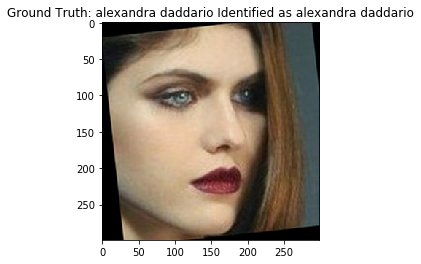

In [39]:
predict(10)

Person belong to folder  pins_Anna Gunn
Original Name : Anna Gu
Predicted Name : Anna Gu
Prediction is CORRECT!!


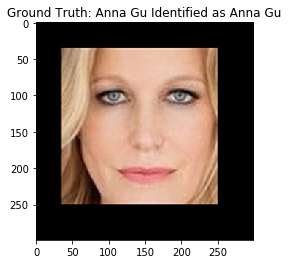

In [40]:
predict(100)

Person belong to folder  pins_Aaron Paul
Original Name : Aaron Paul
Predicted Name : Aaron Paul
Prediction is CORRECT!!


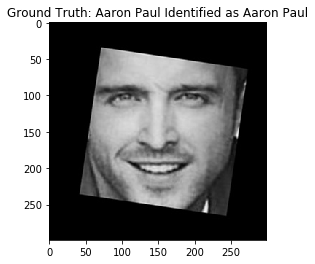

In [41]:
predict(5)